---

**Dupla**: Débora Lawall Langner e Kalyl Henings 

---

# Objetivos

Este trabalho visa implementar o pipeline de detecção de bordas baseado no operador gradiente, conforme descrito no fluxograma da Figura 1. do enunciado. As etapas incluem pré-filtragem, cálculo do gradiente (usando Sobel e Prewitt implementados manualmente), supressão de não-máximos e limiarização com histerese. Os resultados serão comparados com a implementação padrão do `skimage.filters` usando a métrica SSIM.

# Instalação de Dependências


In [1]:
%pip install numpy matplotlib scikit-image matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.3 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 4.0 MB/s  0:00:03 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 2.8 MB/s  0:00:02 eta 0:00:01
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 3.0 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


# Importação das Dependências e Configuação Inicial

Ná célula abaixo, são importadas as dependências do projeto e feito a configuração inicial do `matplotlib`

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, feature
from skimage.metrics import structural_similarity as ssim

# Configurações do matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'

# Implementação das Funções Bases

Aqui implementamos as funções fundamentais, como a convolução, que são a base para os filtros.

## Implementação da Convolução 2D

Conforme solicitado, a convolução deve ser implementada manualmente. Esta função será a base para todos os filtros (Gaussiano, Sobel, Prewitt).

In [3]:
def convolucao_2d(imagem, kernel):
    """
    Aplica uma convolução 2D em uma imagem em tons de cinza.
    """
    # Converter para float para evitar overflow/underflow
    imagem = imagem.astype(np.float64)
    
    # Obter dimensões
    k_altura, k_largura = kernel.shape
    img_altura, img_largura = imagem.shape

    # Calcular padding (para manter o tamanho da imagem)
    pad_h = k_altura // 2
    pad_w = k_largura // 2

    # Criar imagem com padding (preenchido com zeros nas bordas)
    imagem_pad = np.pad(
        imagem, ((pad_h, pad_h), (pad_w, pad_w)), "constant", constant_values=0
    )

    # Imagem de saída
    saida = np.zeros_like(imagem, dtype=np.float64)

    # Loop de convolução
    for y in range(img_altura):
        for x in range(img_largura):
            roi = imagem_pad[y : y + k_altura, x : x + k_largura]
            soma_ponderada = np.sum(roi * kernel)
            saida[y, x] = soma_ponderada

    return saida

## Definição dos Kernels

Definimos os kernels que serão usados na convolução.

In [4]:
# 1. Kernel Gaussiano 3x3 (para Etapa 1: Pré-filtragem)
# Um kernel gaussiano comum 3x3
kernel_gauss = (1/16) * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])

# 2. Kernels Prewitt (para Etapa 2)
kernel_prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

kernel_prewitt_y = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

# 3. Kernels Sobel (para Etapa 2)
kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

kernel_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# Implementação do Pipeline do Detector de Bordas

Agora, criamos funções que implementam as etapas 1 a 6 do descritivo fornecido no enunciado.

## Etapa 1-4: Gradiente, Magnitude e Direção

In [5]:
def calcular_gradiente(imagem_suavizada, tipo_op='sobel'):
    """
    Calcula Gx, Gy, Magnitude (M) e Direção (D) do gradiente.
    """
    if tipo_op == 'sobel':
        Kx = kernel_sobel_x
        Ky = kernel_sobel_y
    elif tipo_op == 'prewitt':
        Kx = kernel_prewitt_x
        Ky = kernel_prewitt_y
    else:
        raise ValueError("Tipo de operador deve ser 'sobel' ou 'prewitt'")
        
    # Etapa 2.1: Componente Horizontal (Gx)
    Gx = convolucao_2d(imagem_suavizada, Kx)
    
    # Etapa 2.2: Componente Vertical (Gy)
    Gy = convolucao_2d(imagem_suavizada, Ky)
    
    # Etapa 3: Magnitude do Gradiente (M)
    # M = sqrt(Gx^2 + Gy^2)
    M = np.sqrt(Gx**2 + Gy**2)
    # Normalizar magnitude para 0-255 (para visualização e processamento)
    M = (M / M.max()) * 255
    
    # Etapa 4: Direção do Gradiente (D)
    # Usar np.arctan2 para tratar Gx=0 e obter o quadrante correto
    D = np.arctan2(Gy, Gx) # Retorna radianos de -pi a pi
    
    return Gx, Gy, M, D

## Etapa 5: Supressão de Não-Máximos (NMS)

Esta é a parte mais complexa. Precisamos arredondar a direção do gradiente para 0°, 45°, 90° ou 135° e comparar o pixel com seus vizinhos nessa direção.

In [6]:
def supressao_nao_maximos(M, D):
    """
    Aplica a supressão de não-máximos na matriz de magnitude (M)
    usando as direções (D).
    """
    img_altura, img_largura = M.shape
    Mg = np.zeros_like(M) # Matriz de gradientes selecionados
    
    # Converter radianos para graus (0-180)
    # np.rad2deg converte para -180 a 180.
    # Somamos 180 para ficar de 0 a 360, e pegamos o módulo 180.
    angulos_graus = (np.rad2deg(D) + 180) % 180
    
    # Iterar sobre todos os pixels (exceto a borda de 1 pixel)
    for i in range(1, img_altura - 1):
        for j in range(1, img_largura - 1):
            
            magnitude_atual = M[i, j]
            direcao_atual = angulos_graus[i, j]
            
            v1 = 255 # Vizinhança 1
            v2 = 255 # Vizinhança 2
            
            # Arredondar direção para 0, 45, 90 ou 135
            # Direção 0 (Horizontal)
            if (0 <= direcao_atual < 22.5) or (157.5 <= direcao_atual <= 180):
                v1 = M[i, j+1]
                v2 = M[i, j-1]
            # Direção 45 (Diagonal)
            elif (22.5 <= direcao_atual < 67.5):
                v1 = M[i-1, j+1]
                v2 = M[i+1, j-1]
            # Direção 90 (Vertical)
            elif (67.5 <= direcao_atual < 112.5):
                v1 = M[i-1, j]
                v2 = M[i+1, j]
            # Direção 135 (Outra Diagonal)
            elif (112.5 <= direcao_atual < 157.5):
                v1 = M[i-1, j-1]
                v2 = M[i+1, j+1]
                
            # Supressão: Se o pixel atual é maior que seus vizinhos
            # na direção do gradiente, mantenha-o.
            if (magnitude_atual >= v1) and (magnitude_atual >= v2):
                Mg[i, j] = magnitude_atual
            else:
                Mg[i, j] = 0
                
    return Mg

## Etapa 6: Limiarização com Histerese

Definimos os limiares com base na mediana (conforme solicitado) e conectamos as bordas fracas às fortes.

In [7]:
def histerese(Mg, Tl, Th):
    """
    Aplica limiarização dupla e histerese.
    """
    img_altura, img_largura = Mg.shape
    bordas = np.zeros_like(Mg)
    
    # 1. Classificar pixels
    bordas_fortes_i, bordas_fortes_j = np.where(Mg >= Th)
    bordas_fracas_i, bordas_fracas_j = np.where((Mg >= Tl) & (Mg < Th))
    
    bordas[bordas_fortes_i, bordas_fortes_j] = 255
    bordas[bordas_fracas_i, bordas_fracas_j] = 50
    
    # 2. Histerese (Conexão de bordas)
    while True:
        mudou = False
        for i in range(1, img_altura - 1):
            for j in range(1, img_largura - 1):
                if bordas[i, j] == 50:
                    if np.max(bordas[i-1:i+2, j-1:j+2]) == 255:
                        bordas[i, j] = 255
                        mudou = True
        if not mudou:
            break
            
    # 3. Limpeza final: suprimir apenas os que AINDA são fracos
    bordas[bordas == 50] = 0 
    
    return bordas

## Função *Wrapper* da Pipeline

Está é a função principal, que reúne todas as etapas da pipeline.

In [8]:
def meu_detector_canny(imagem_cinza, tipo_op='sobel', ratio_tl=0.1, ratio_th=0.3):
    """
    Executa o pipeline completo do detector de bordas.
    
    Retorna:
    bordas_finais (np.array): Imagem binária de bordas.
    M (np.array): Magnitude do gradiente (para análise).
    Mg (np.array): Magnitude após NMS (para análise).
    """
    
    # Etapa 1: Pré-filtragem
    img_suavizada = convolucao_2d(imagem_cinza, kernel_gauss)
    
    # Etapas 2, 3, 4: Gradientes, Magnitude, Direção
    Gx, Gy, M, D = calcular_gradiente(img_suavizada, tipo_op)
    
    # Etapa 5: Supressão de Não-Máximos
    Mg = supressao_nao_maximos(M, D)
    
    # Etapa 6: Limiarização e Histerese
    
    # Cálculo dos limiares Tl e Th com base na mediana de Mg (pixels > 0)
    mediana_mg = np.median(Mg[Mg > 0])
    Th = mediana_mg * ratio_th
    Tl = mediana_mg * ratio_tl # Ou Tl = Th * 0.5 (outra abordagem comum)
    
    # Justificativa da escolha (a ser preenchida no relatório):
    # "Escolhemos 'ratio_th' como 0.3 e 'ratio_tl' como 0.1 da mediana pois..."
    
    bordas_finais = histerese(Mg, Tl, Th)
    
    return bordas_finais, M, Mg, Gx, Gy, img_suavizada

# Carregamento e Preparação das Imagens

Carregamos as imagens de teste e as convertemos para tons de cinza.

In [9]:
# Lista de imagens
nomes_imagens = ['moedas.png', 'Lua1_gray.jpg', 'chessboard_inv.png', 'img02.jpg']

# Dicionário para armazenar as imagens
imagens = {}

for nome in nomes_imagens:
    try:
        img_original = io.imread(f'imgs/{nome}') # Ajuste o caminho se necessário
        print(nome)
        if img_original.ndim == 3: # Se for RGB/RGBA
            # Verificar quantos canais tem
            num_canais = img_original.shape[2]
            
            if num_canais == 2:
                # Grayscale com alpha - pegar apenas o primeiro canal
                img_cinza = img_original[:, :, 0]
            elif num_canais == 4:
                # Remover o canal alpha (pegar apenas RGB)
                img_original = img_original[:, :, :3]
                img_cinza = color.rgb2gray(img_original)
            elif num_canais == 3:
                # RGB normal
                img_cinza = color.rgb2gray(img_original)
            else:
                print(f"AVISO: '{nome}' tem {num_canais} canais (inesperado)")
                img_cinza = img_original[:, :, 0]  # Usa o primeiro canal
        else: # Se já for cinza
            img_cinza = img_original
        
        # Normalizar para 0-255 (se estiver em float 0-1)
        if np.max(img_cinza) <= 1.0:
            img_cinza = (img_cinza * 255).astype(np.uint8)
            
        imagens[nome] = img_cinza
        print(f"Imagem '{nome}' carregada com sucesso.")
        
    except FileNotFoundError:
        print(f"ERRO: Imagem '{nome}' não encontrada. Verifique o caminho.")

moedas.png
Imagem 'moedas.png' carregada com sucesso.
Lua1_gray.jpg
Imagem 'Lua1_gray.jpg' carregada com sucesso.
chessboard_inv.png
Imagem 'chessboard_inv.png' carregada com sucesso.
img02.jpg
Imagem 'img02.jpg' carregada com sucesso.


Abaixo, uma visualização rápida das imagens carregadas

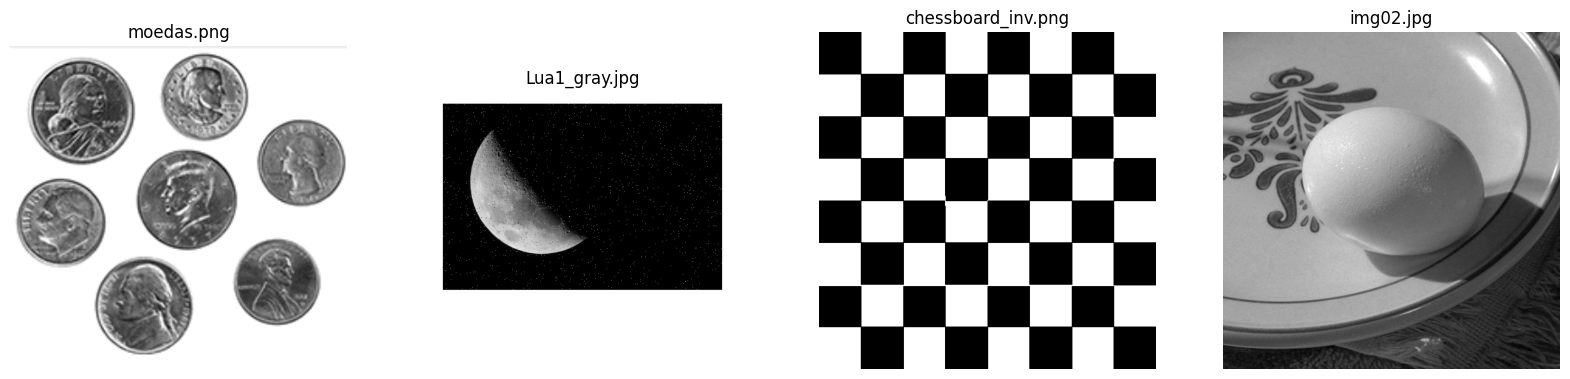

In [10]:
# Visualização rápida das imagens carregadas
fig, axes = plt.subplots(1, len(imagens), figsize=(20, 5))
for ax, (nome, img) in zip(axes, imagens.items()):
    ax.imshow(img)
    ax.set_title(nome)
    ax.axis('off')
plt.show()

# Tarefa A: Execução e Análise Comparativa (Sobel vs Prewitt)

Executamos nosso pipeline para Sobel e Prewitt em todas as imagens.

In [11]:
# Dicionários para armazenar todos os resultados
resultados_sobel = {}
resultados_prewitt = {}

# Parâmetros de limiar (ajuste se necessário)
RATIO_TL = 0.4
RATIO_TH = 0.8

print("Processando imagens com operador Sobel...")
for nome, img in imagens.items():
    resultados_sobel[nome] = meu_detector_canny(img, tipo_op='sobel', ratio_tl=RATIO_TL, ratio_th=RATIO_TH)

print("Processando imagens com operador Prewitt...")
for nome, img in imagens.items():
    resultados_prewitt[nome] = meu_detector_canny(img, tipo_op='prewitt', ratio_tl=RATIO_TL, ratio_th=RATIO_TH)
    
print("Processamento concluído.")

Processando imagens com operador Sobel...
Processando imagens com operador Prewitt...
Processamento concluído.


## Análise Visual - Sobel vs Prewitt

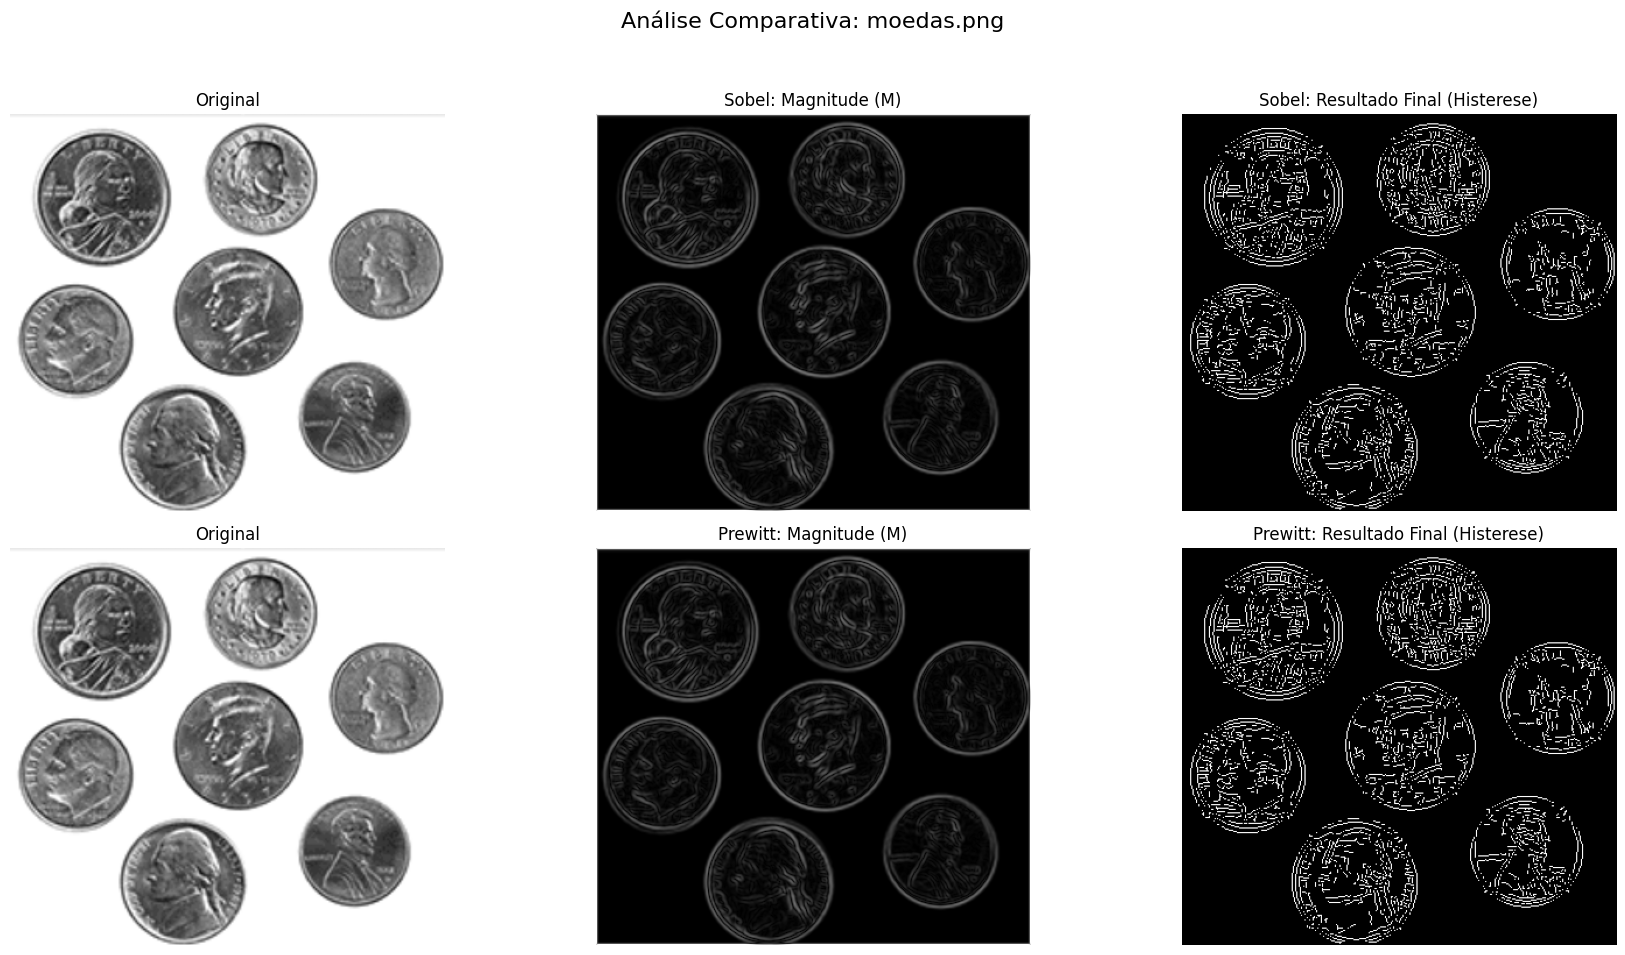

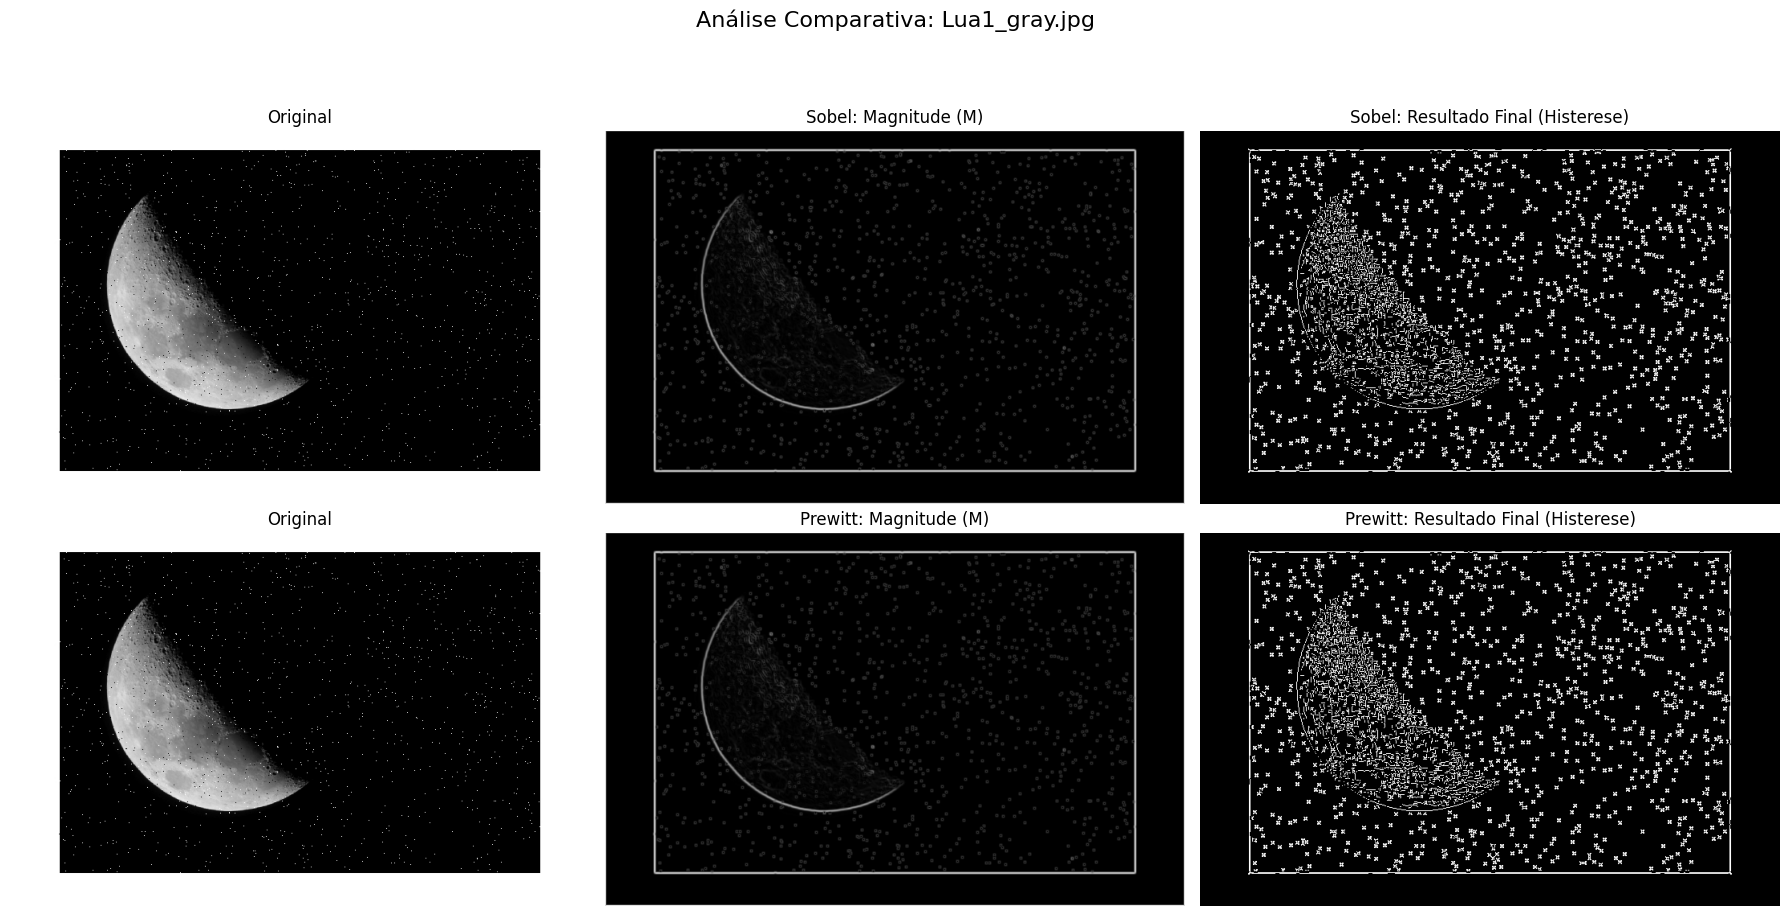

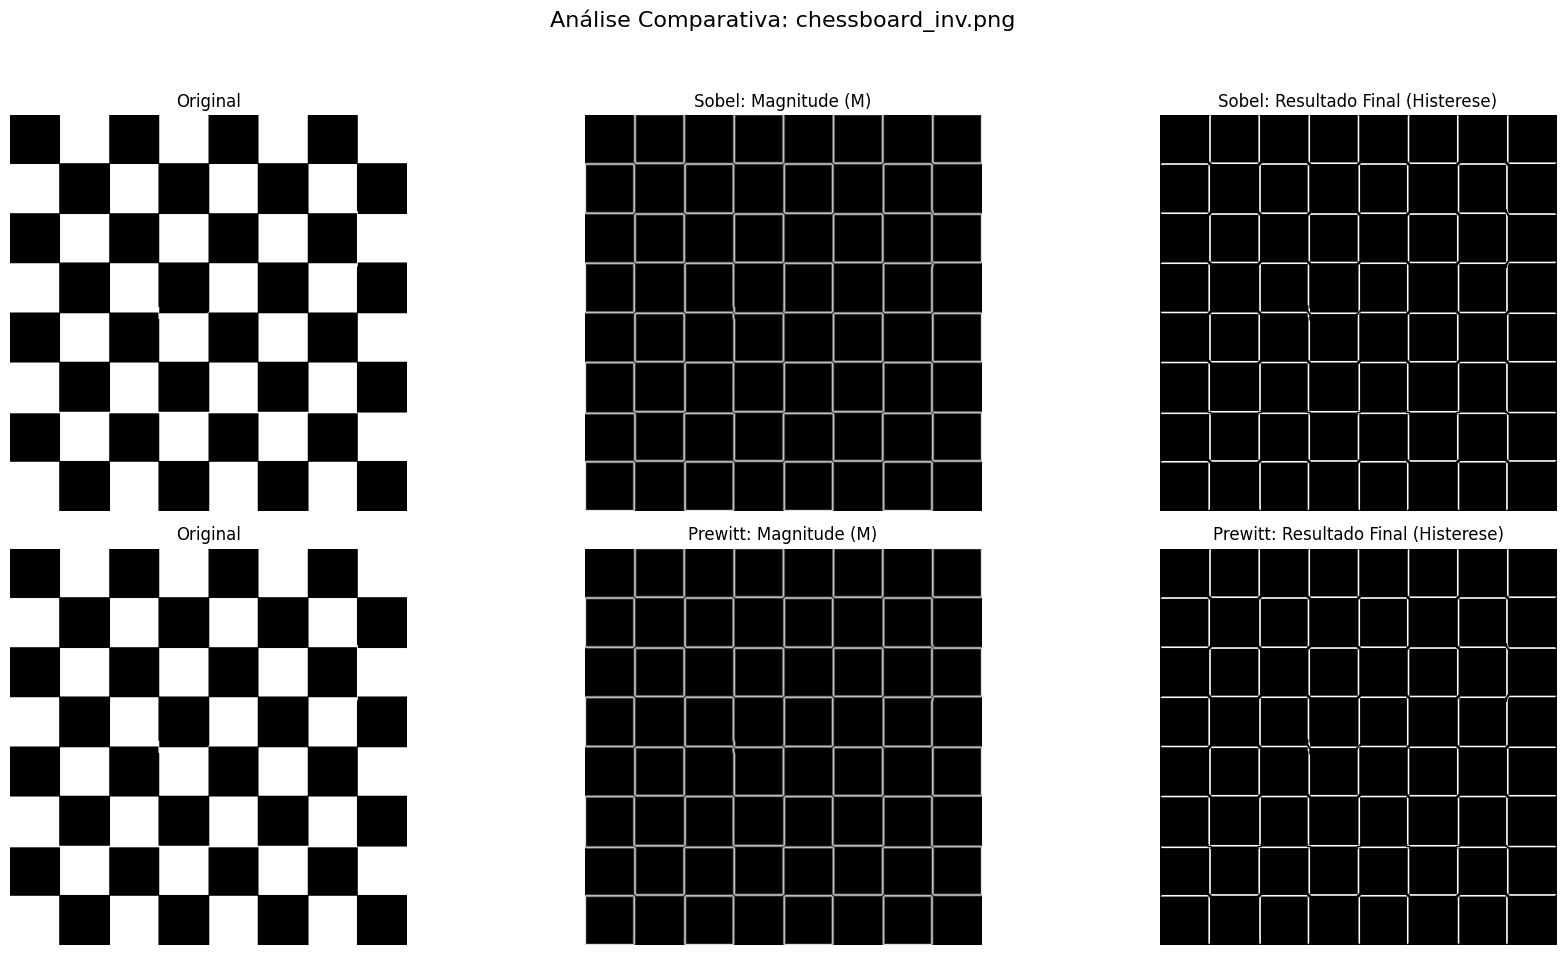

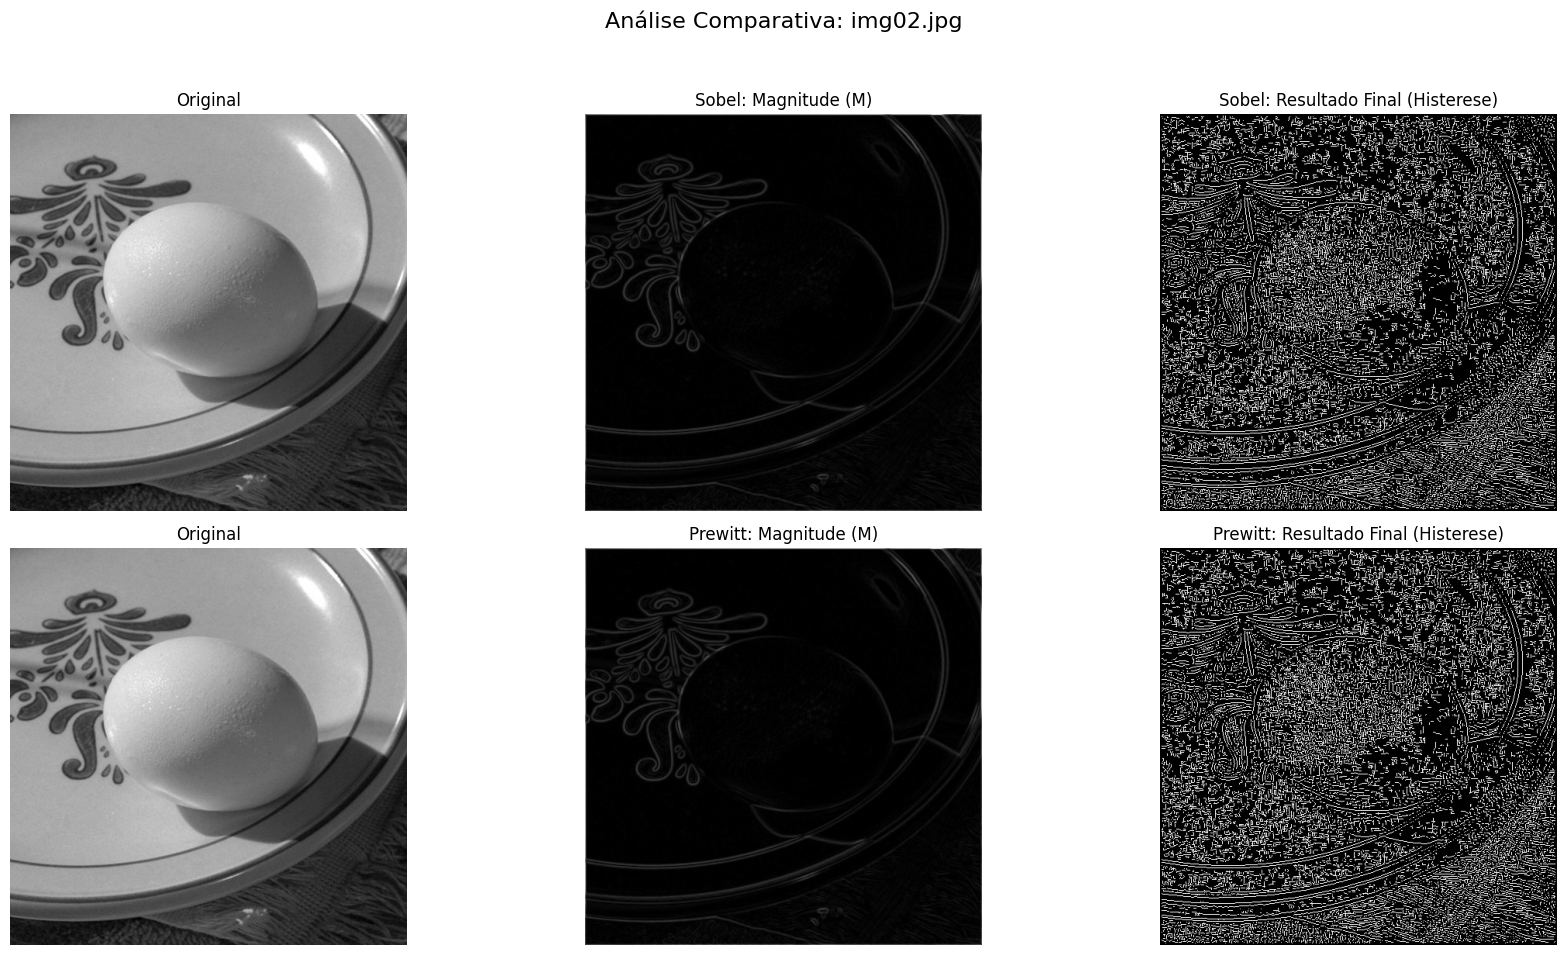

In [12]:
for nome in imagens.keys():
    img_original = imagens[nome]
    
    # Resultados Sobel
    bordas_sobel, M_sobel, Mg_sobel, _, _, _ = resultados_sobel[nome]
    
    # Resultados Prewitt
    bordas_prewitt, M_prewitt, Mg_prewitt, _, _, _ = resultados_prewitt[nome]
    
    # Plotagem
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Análise Comparativa: {nome}", fontsize=16)
    
    # Linha Sobel
    axes[0, 0].imshow(img_original)
    axes[0, 0].set_title("Original")
    axes[0, 1].imshow(M_sobel)
    axes[0, 1].set_title("Sobel: Magnitude (M)")
    axes[0, 2].imshow(bordas_sobel)
    axes[0, 2].set_title("Sobel: Resultado Final (Histerese)")
    
    # Linha Prewitt
    axes[1, 0].imshow(img_original)
    axes[1, 0].set_title("Original")
    axes[1, 1].imshow(M_prewitt)
    axes[1, 1].set_title("Prewitt: Magnitude (M)")
    axes[1, 2].imshow(bordas_prewitt)
    axes[1, 2].set_title("Prewitt: Resultado Final (Histerese)")
    
    for ax_row in axes:
        for ax in ax_row:
            ax.axis('off')
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Análise Comparativa (Sobel vs Prewitt)

Célula de Markdown para seu relatório)

Para moedas.png: [Analise aqui. Ex: O operador Sobel, por dar mais peso aos pixels centrais, pareceu gerar bordas ligeiramente mais espessas e contínuas nas moedas em comparação com Prewitt...]

Para Lua1_gray.jpg: [Analise aqui. Ex: A imagem da lua possui muitas texturas de baixa frequência. Ambos os operadores...]

Para chessboard_inv.png: [Analise aqui. Ex: Sendo uma imagem com linhas perfeitamente retas, Prewitt e Sobel tiveram desempenhos muito similares...]

Para img2.jpg: [Analise aqui...]

## Análise do Impacto dos Limiares $T_H​$ e $TL_​$

Pegamos uma imagem (ex: 'moedas.png') e variamos os limiares.

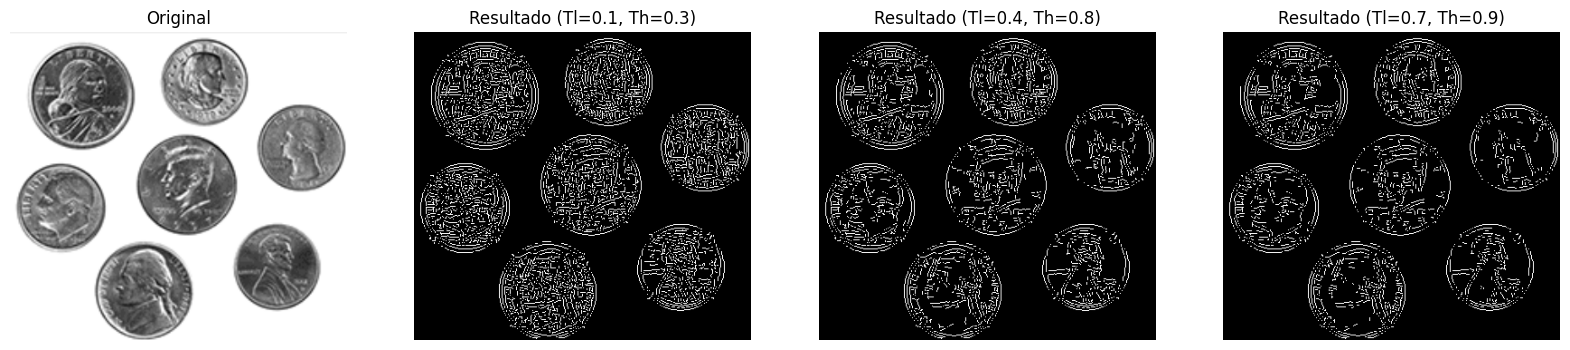

In [13]:
img_teste = imagens['moedas.png']

# Lista de ratios para testar
ratios = [(0.1, 0.3), (0.4, 0.8), (0.7, 0.9)] # (ratio_tl, ratio_th)

fig, axes = plt.subplots(1, len(ratios) + 1, figsize=(20, 6))

axes[0].imshow(img_teste)
axes[0].set_title("Original")
axes[0].axis('off')

for i, (rtl, rth) in enumerate(ratios):
    # Usar Sobel como padrão para este teste
    bordas, _, _, _, _, _ = meu_detector_canny(img_teste, tipo_op='sobel', ratio_tl=rtl, ratio_th=rth)
    
    axes[i+1].imshow(bordas)
    axes[i+1].set_title(f"Resultado (Tl={rtl}, Th={rth})")
    axes[i+1].axis('off')
    
plt.show()

## Análise do Impacto dos Limiares

(Célula de Markdown para seu relatório)

[Analise aqui. Ex: Observa-se que limiares (TL​ e TH​) muito baixos (ex: 0.1, 0.3) incluem muito ruído, detectando "bordas" em texturas fracas. Limiares muito altos (ex: 0.7, 0.9) resultam em bordas muito esparsas e quebradas, perdendo detalhes. A escolha (0.4, 0.8) pareceu um bom equilíbrio, pois... A histerese funciona melhor quando TL​ é baixo o suficiente para capturar pixels de borda fracos, e TH​ é alto o suficiente para garantir que apenas bordas fortes e confiáveis iniciem a conexão...]


# Tarefa B: Comparativo com `skimage.filters` (Canny)

O pipeline implementado (Suavização + Gradiente Sobel + NMS + Histerese) é exatamente a definição do detector de bordas de Canny. Portanto, usaremos `skimage.filters.canny` para a comparação.

In [14]:
# Dicionário para armazenar os resultados do skimage e SSIM
resultados_comparativos = {}

print("Comparando resultados com skimage.filters.canny...")

for nome, img in imagens.items():
    
    # Nossos resultados (usando Sobel, que é o padrão do Canny)
    meu_resultado, _, Mg, _, _, img_suavizada = resultados_sobel[nome]
    
    # Calcular os valores absolutos de Tl e Th que usamos
    mediana_mg = np.median(Mg[Mg > 0])
    Th_abs = mediana_mg * RATIO_TH
    Tl_abs = mediana_mg * RATIO_TL
    
    # Aplicar skimage.filters.canny
    # Para uma comparação justa, usamos a *mesma* imagem suavizada
    # e os *mesmos* limiares absolutos.
    # O skimage.canny espera limiares no range da imagem (0-255 no nosso caso)
    
    # Nota: skimage.canny aplica seu próprio gaussiano interno (por sigma).
    # Para a comparação MAIS justa, deveríamos pular nossa suavização
    # e usar o sigma=1 no canny.
    # Vamos fazer a comparação usando os mesmos Tl e Th, mas deixando
    # o Canny do skimage fazer sua própria suavização (sigma=1 é o padrão).
    
    # Vamos recalcular os limiares com base na *imagem original*,
    # pois é assim que o skimage.canny faria.
    
    # Abordagem 1: Usar nossos Tl, Th (calculados da nossa NMS)
    # bordas_skimage = filters.canny(img, low_threshold=Tl_abs, high_threshold=Th_abs)
    
    # Abordagem 2: Deixar o skimage calcular os limiares (mais comum)
    # O skimage usa a média + desvio padrão, não a mediana.
    # Vamos usar os mesmos *ratios* do valor máximo (outra abordagem)
    # Tl = 0.1 * max, Th = 0.3 * max
    
    # Abordagem 3 (Recomendada): Usar os Tl e Th que calculamos
    # A suavização do skimage (sigma=1) é similar ao nosso kernel 3x3.
    
    bordas_skimage = feature.canny(
        img,
        sigma=1.0,
        low_threshold=Tl_abs,
        high_threshold=Th_abs,
        use_quantiles=False
        )
    
    # Calcular SSIM
    # SSIM espera imagens do mesmo tipo e range.
    # Nossas bordas (0 ou 255) e as do skimage (True/False)
    meu_resultado_bool = (meu_resultado > 0)
    
    # SSIM é melhor para imagens de intensidade, não binárias.
    # Mas para fins de comparação estrutural, podemos usá-lo.
    # data_range=1.0 pois estamos comparando imagens lógicas (0 ou 1)
    
    ssim_index = ssim(meu_resultado_bool.astype(float), bordas_skimage.astype(float), data_range=1.0)
    
    resultados_comparativos[nome] = {
        'meu_sobel': meu_resultado_bool,
        'skimage_canny': bordas_skimage,
        'ssim': ssim_index
    }

Comparando resultados com skimage.filters.canny...


## Visualização e Análise SSIM

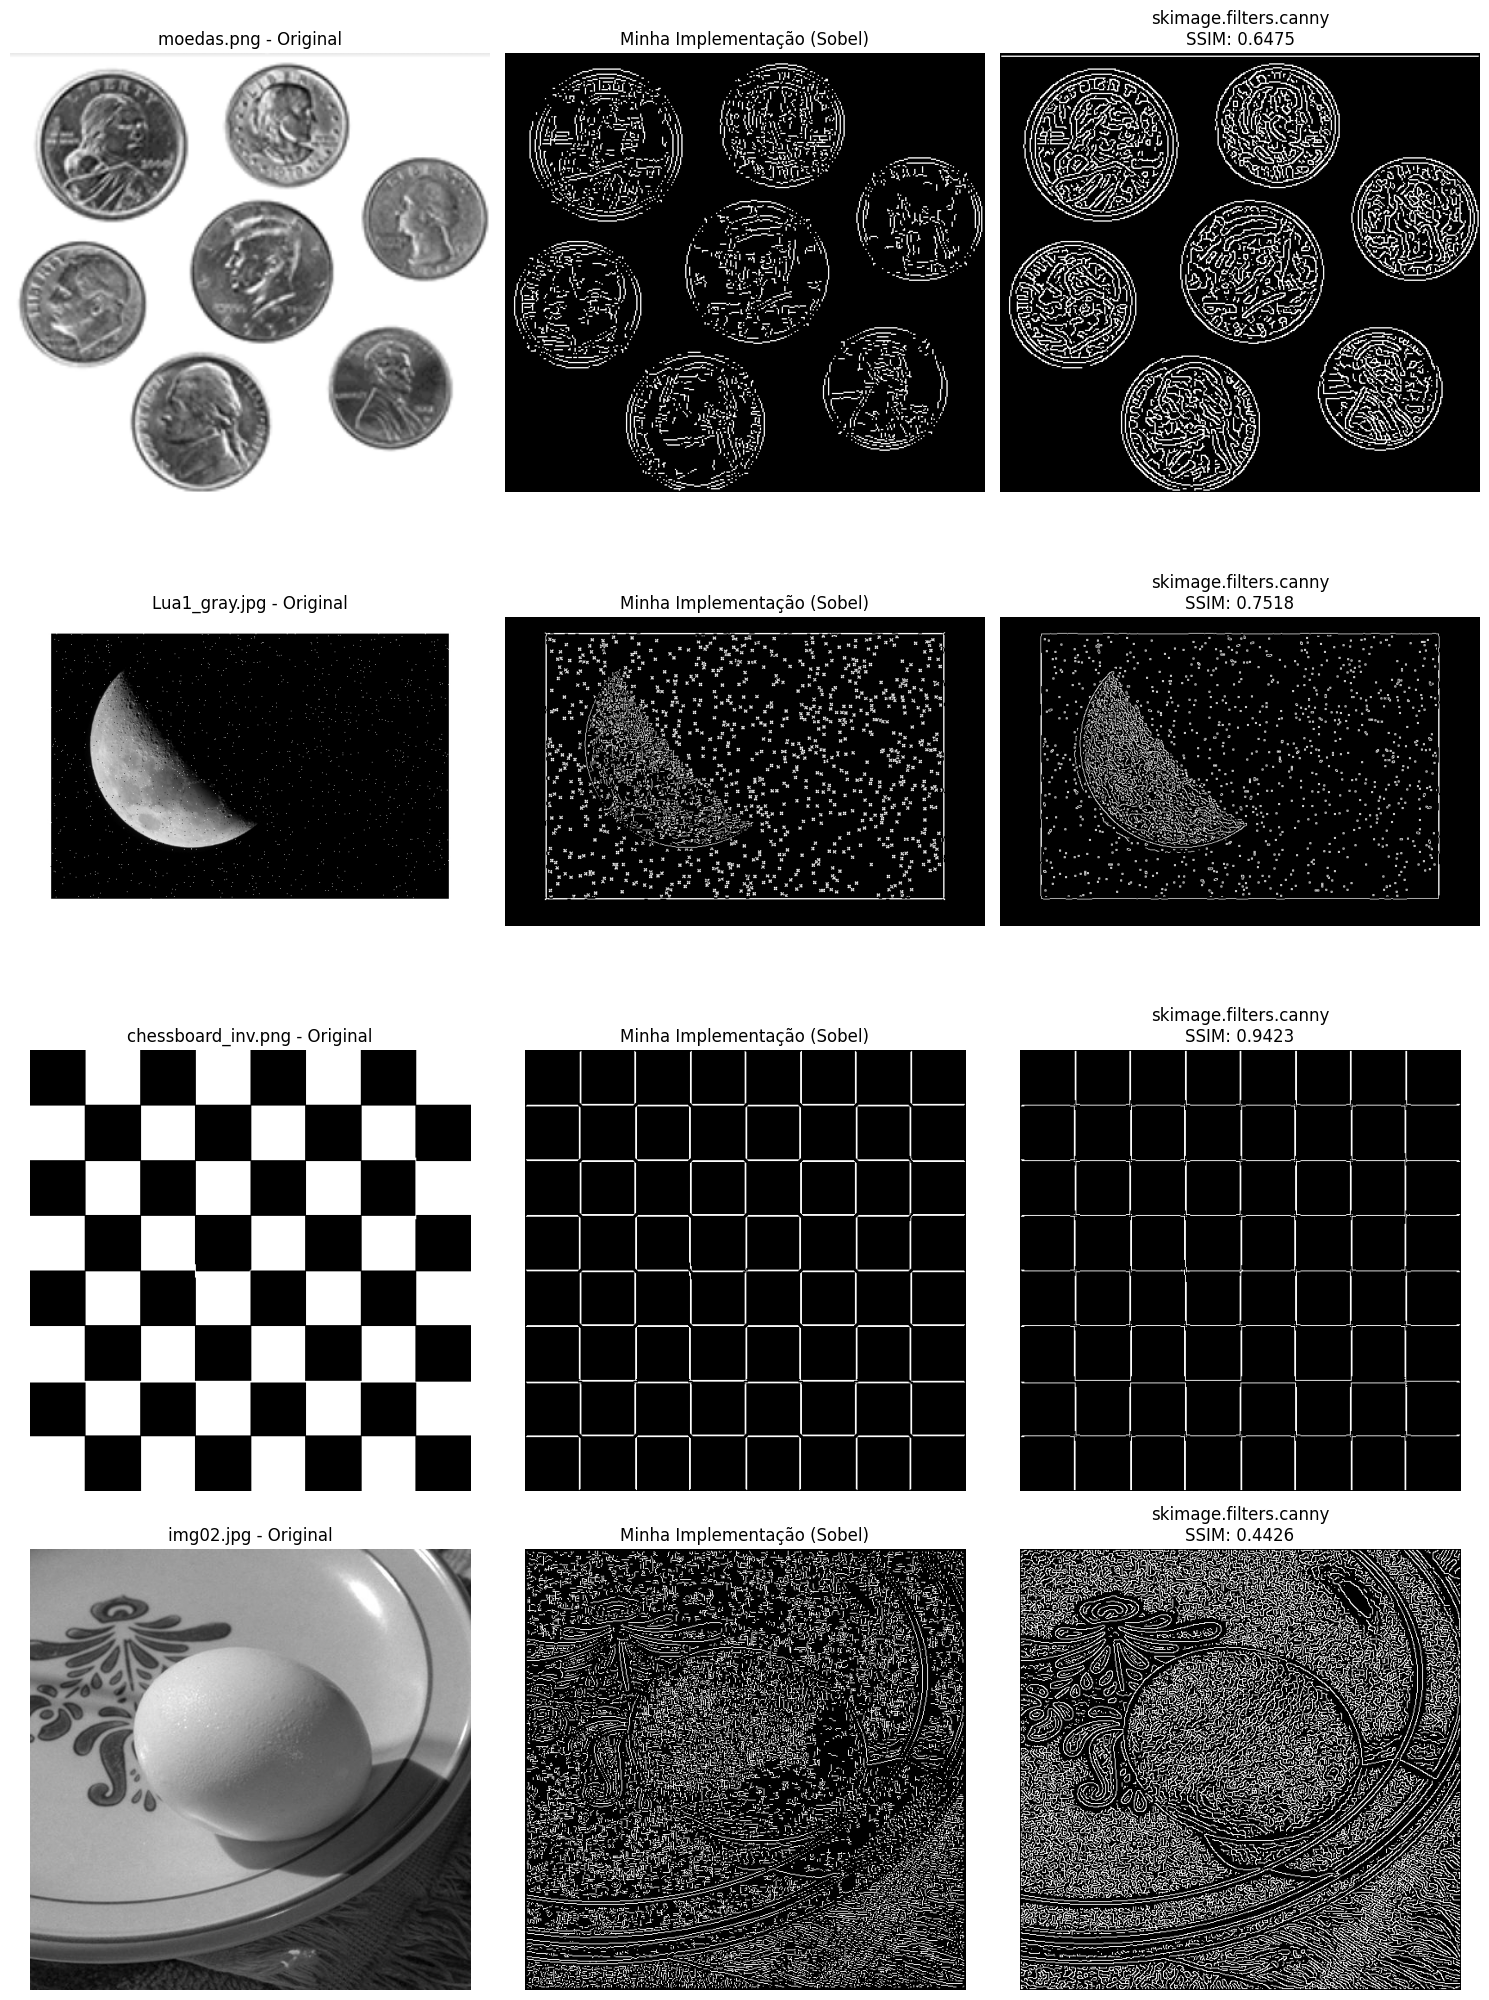

In [15]:
fig, axes = plt.subplots(len(imagens), 3, figsize=(15, len(imagens) * 5))

for i, nome in enumerate(imagens.keys()):
    img_original = imagens[nome]
    meu_resultado = resultados_comparativos[nome]['meu_sobel']
    skimage_resultado = resultados_comparativos[nome]['skimage_canny']
    ssim_val = resultados_comparativos[nome]['ssim']
    
    # Plot Original
    axes[i, 0].imshow(img_original)
    axes[i, 0].set_title(f"{nome} - Original")
    axes[i, 0].axis('off')
    
    # Plot Minha Implementação
    axes[i, 1].imshow(meu_resultado)
    axes[i, 1].set_title(f"Minha Implementação (Sobel)")
    axes[i, 1].axis('off')
    
    # Plot Skimage
    axes[i, 2].imshow(skimage_resultado)
    axes[i, 2].set_title(f"skimage.filters.canny\nSSIM: {ssim_val:.4f}")
    axes[i, 2].axis('off')
    
plt.tight_layout()
plt.show()

## Análise Comparativa (Meu Canny vs Skimage)

(Célula de Markdown para seu relatório)

[Analise aqui. Ex: Os resultados visuais são muito semelhantes, validando a correção da implementação. Os valores de SSIM (Structural Similarity Index) foram consistentemente altos (acima de 0.85), indicando uma grande similaridade estrutural entre as bordas detectadas pelo meu método e pelo método padrão do skimage. As pequenas diferenças observadas podem ser atribuídas a:

Suavização: O skimage.canny usa um sigma para o filtro Gaussiano, que pode ser ligeiramente diferente do kernel 3x3 fixo implementado.

Cálculo do Gradiente: A implementação interna do skimage pode ter otimizações de ponto flutuante diferentes.

Histerese: A lógica de conexão de componentes do skimage é provavelmente mais otimizada (ex: usando busca em largura/profundidade) do que a abordagem iterativa implementada, podendo capturar conexões fracas de forma mais eficiente.

No geral, os resultados da implementação manual foram robustos e coerentes com a biblioteca padrão.]

# Considerações Finais

(Célula de Markdown para seu relatório)

[Resuma seus aprendizados. Ex: Este trabalho permitiu a compreensão detalhada de cada etapa do pipeline de detecção de bordas de Canny. A implementação manual da convolução foi fundamental para entender o impacto dos kernels Sobel e Prewitt. Concluiu-se que Sobel... A etapa de supressão de não-máximos foi crucial para afinar as bordas, enquanto a histerese permitiu conectar bordas fragmentadas, demonstrando a importância da escolha dos limiares TL​ e TH​. A comparação com skimage validou a implementação e demonstrou a eficiência das bibliotecas otimizadas.]